Notebook for Market Analysis

In [69]:
import pandas as pd

In [70]:
df = pd.read_csv("../data/processed/listings_clean.csv", low_memory=False)

In [71]:
df.head()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,...,price_ratio,price_per_sqft,days_on_market,yr_month,listing_to_contract_days,contract_to_close_days,index_right,DistrictNa,PriceRatio,outlier_flag
0,1400000.0,1076193814,NaN,NaN,33.858559,-116.542169,505 E Molino Road,Residential,2256.0,1400000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,478.0,Palm Springs Unified,NaN,False
1,199990.0,1076192982,NaN,NaN,32.777540,-115.553772,1826 S 4th Street,Residential,1024.0,199990.0,...,NaN,NaN,NaN,NaN,NaN,NaN,149.0,Central Union High,NaN,False
2,199990.0,1076192982,NaN,NaN,32.777540,-115.553772,1826 S 4th Street,Residential,1024.0,199990.0,...,NaN,NaN,NaN,NaN,NaN,NaN,150.0,El Centro Elementary,NaN,False
3,835000.0,1076190486,NaN,NaN,33.166112,-117.266548,4645 Cordoba Way,Residential,1444.0,835000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,582.0,Vista Unified,NaN,False
4,1150000.0,1076190201,NaN,NaN,33.212280,-117.218628,1517 Via Pedro,Residential,3309.0,1150000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,582.0,Vista Unified,NaN,False


In [72]:
sd_df = df[df['CountyOrParish'] == 'San Diego']

In [73]:
sd_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48530 entries, 3 to 563819
Data columns (total 67 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   OriginalListPrice            48530 non-null  float64
 1   ListingKey                   48530 non-null  int64  
 2   CloseDate                    15168 non-null  object 
 3   ClosePrice                   15164 non-null  float64
 4   Latitude                     48530 non-null  float64
 5   Longitude                    48530 non-null  float64
 6   UnparsedAddress              48425 non-null  object 
 7   PropertyType                 48530 non-null  object 
 8   LivingArea                   48530 non-null  float64
 9   ListPrice                    48530 non-null  float64
 10  DaysOnMarket                 48530 non-null  int64  
 11  ListOfficeName               48530 non-null  object 
 12  BuyerOfficeName              15161 non-null  object 
 13  CoListOfficeName    

<Axes: title={'center': 'Property Type Distribution in San Diego County'}, xlabel='PropertyType'>

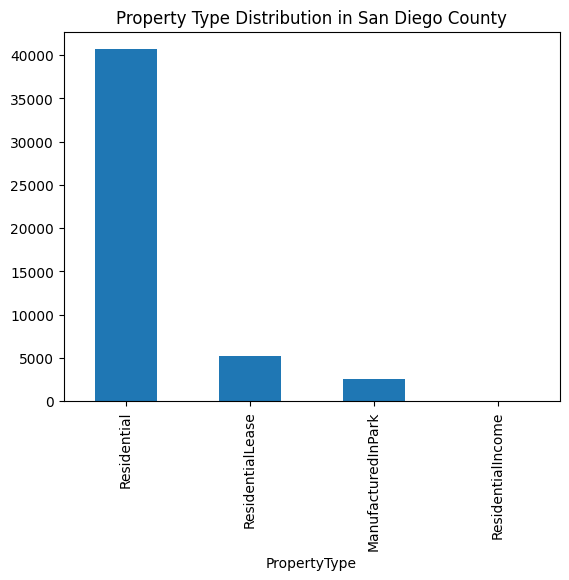

In [74]:
sd_df.value_counts('PropertyType').plot(kind='bar', title='Property Type Distribution in San Diego County')

In [75]:
sd_resi_df = sb_df[sb_df['PropertyType'] == 'Residential']

<Axes: title={'center': 'Residential Property Subtype Distribution in San Diego County'}, xlabel='PropertySubType'>

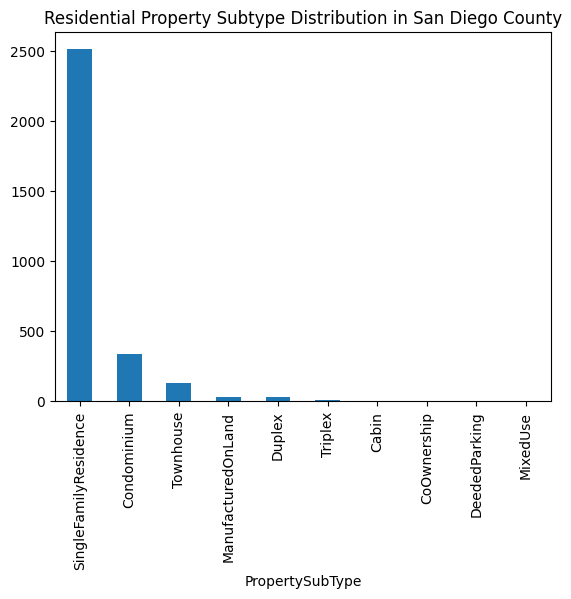

In [76]:
sd_resi_df.value_counts('PropertySubType').plot(kind='bar', title='Residential Property Subtype Distribution in San Diego County')

<Axes: title={'center': 'Average List Price by Residential Property Subtype in San Diego County'}, xlabel='PropertySubType'>

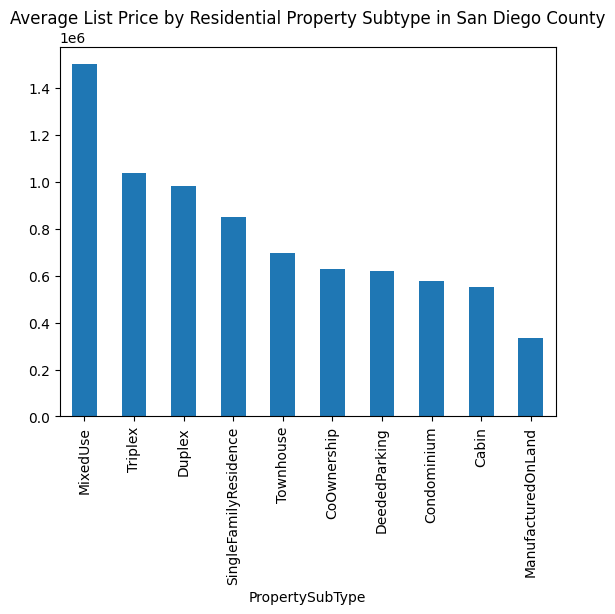

In [77]:
sd_resi_df.groupby('PropertySubType')['ListPrice'].mean().sort_values(ascending=False).plot(kind='bar', title='Average List Price by Residential Property Subtype in San Diego County')

<Axes: title={'center': 'Average List Price Over Time for Residential Properties in San Diego County'}, xlabel='year_month'>

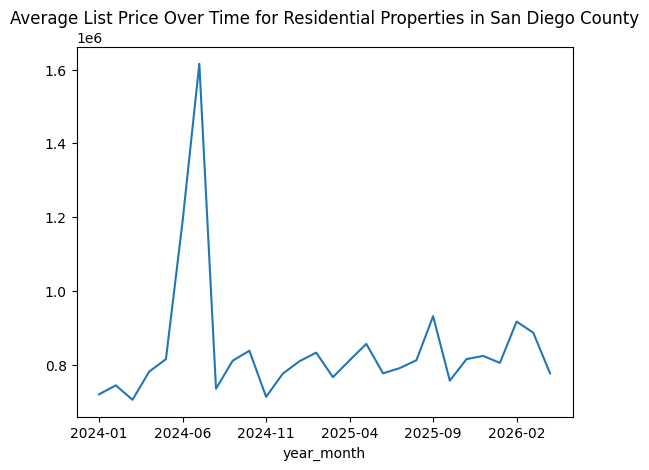

In [78]:
sd_resi_df.groupby('year_month')['ListPrice'].mean().plot(kind='line', title='Average List Price Over Time for Residential Properties in San Diego County')

<Axes: title={'center': 'Residential Property Distribution by Listing Agent in San Diego County'}, xlabel='ListAgentFullName'>

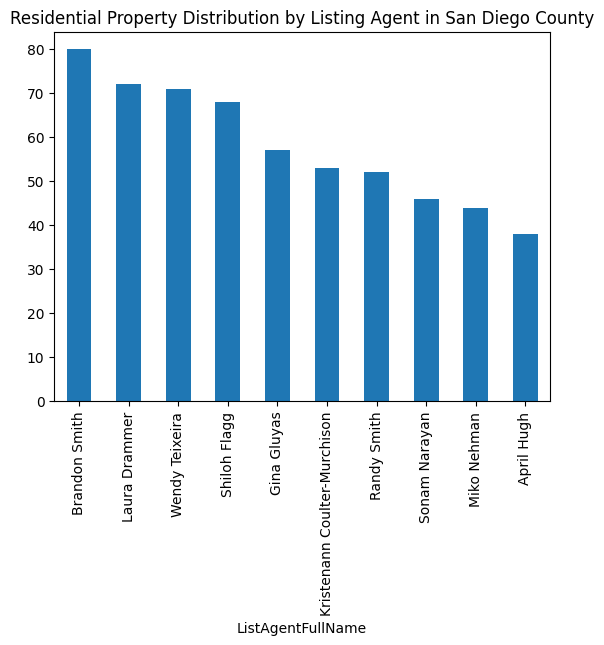

In [79]:
sd_resi_df.value_counts('ListAgentFullName').head(10).plot(kind='bar', title='Residential Property Distribution by Listing Agent in San Diego County')

<Axes: title={'center': 'Residential Property Distribution by Listing Agent in San Diego County'}, xlabel='BuyerOfficeName'>

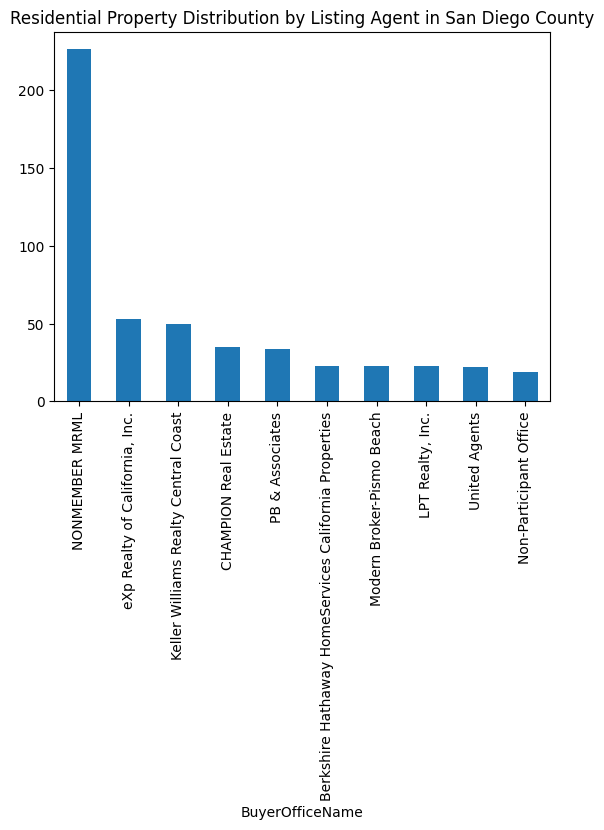

In [80]:
sd_resi_df.value_counts('BuyerOfficeName').head(10).plot(kind='bar', title='Residential Property Distribution by Listing Agent in San Diego County')

<Axes: title={'center': 'Average Days on Market for Residential Properties in San Diego County'}, xlabel='year_month'>

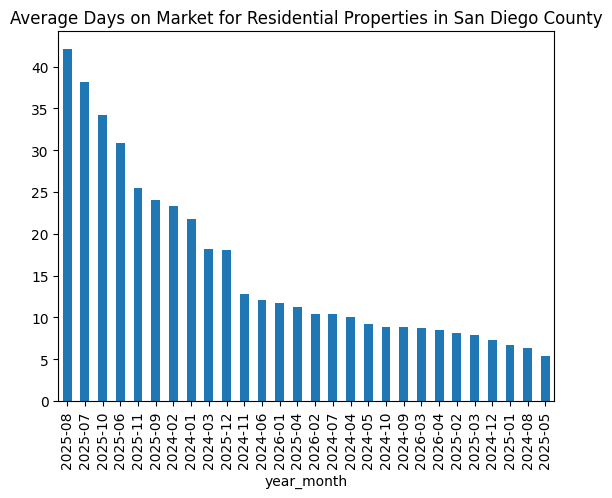

In [81]:
sd_resi_df.groupby('year_month')['DaysOnMarket'].mean().sort_values(ascending=False).plot(kind='bar', title='Average Days on Market for Residential Properties in San Diego County')

In [82]:
sd_resi_df['DaysOnMarket'].describe()

count    3053.000000
mean       16.066492
std        24.482491
min         0.000000
25%         4.000000
50%         8.000000
75%        17.000000
max       224.000000
Name: DaysOnMarket, dtype: float64

<Axes: title={'center': 'Average Close Price for Residential Properties in San Diego County'}, xlabel='year_month'>

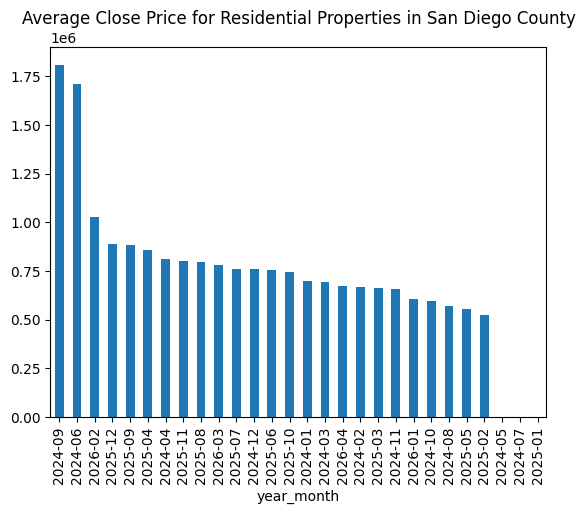

In [83]:
sd_resi_df.groupby('year_month')['ClosePrice'].mean().sort_values(ascending=False).plot(kind='bar', title='Average Close Price for Residential Properties in San Diego County')

/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_72331/1214119650.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  close_price_pct_change = sd_resi_df.groupby('year_month')['ClosePrice'].mean().pct_change()


<Axes: title={'center': 'Average Close Price Percentage Change Over Time for Residential Properties in San Diego County'}, xlabel='year_month'>

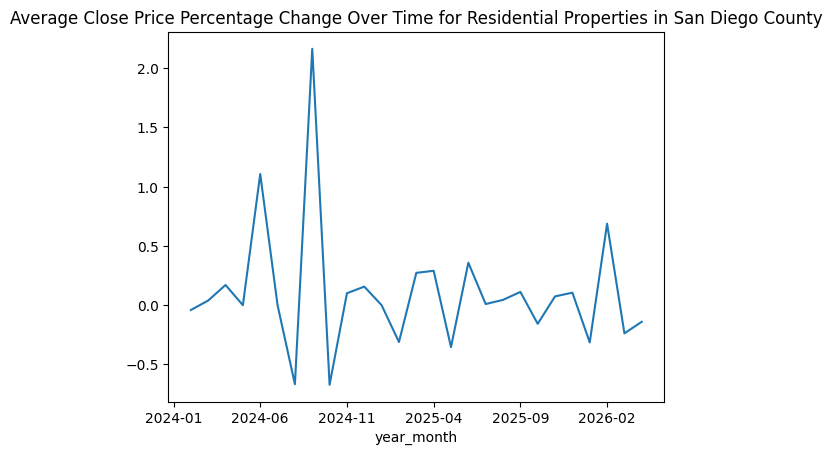

In [84]:
# close price trend

close_price_pct_change = sd_resi_df.groupby('year_month')['ClosePrice'].mean().pct_change()

close_price_pct_change.plot(kind='line', title='Average Close Price Percentage Change Over Time for Residential Properties in San Diego County')

In [85]:
sd_resi_df['PricePerSqFt'] = sd_resi_df['ClosePrice'] / sd_resi_df['LivingArea']

sd_resi_df['PricePerSqFt'].replace([float('inf'), -float('inf')], float('nan'), inplace=True)


/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_72331/1850899391.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sd_resi_df['PricePerSqFt'] = sd_resi_df['ClosePrice'] / sd_resi_df['LivingArea']
/var/folders/9w/27dwnd7s3plbp9xj1v9qrn5m0000gn/T/ipykernel_72331/1850899391.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform t

<Axes: title={'center': 'Average Price Per Square Foot for Residential Properties in San Diego County'}, xlabel='year_month'>

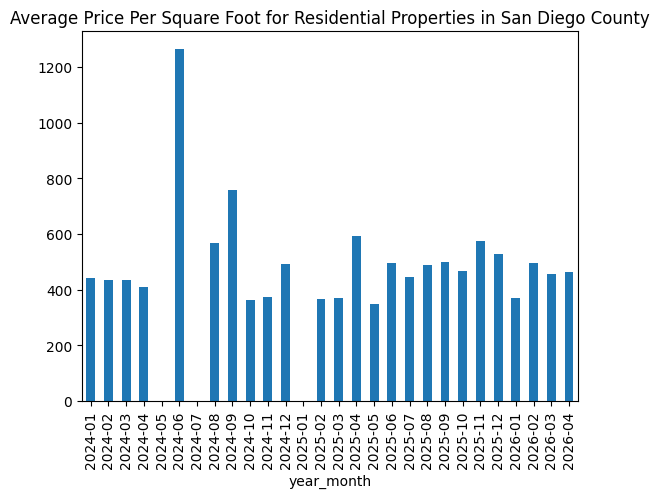

In [86]:
sd_resi_df.groupby('year_month')['PricePerSqFt'].mean().plot(kind='bar', title='Average Price Per Square Foot for Residential Properties in San Diego County', )

In [87]:
sd_resi_df.groupby('year_month')['PricePerSqFt'].mean()

year_month
2024-01     443.546752
2024-02     434.143055
2024-03     435.191841
2024-04     407.828965
2024-05            NaN
2024-06    1264.882783
2024-07            NaN
2024-08     567.055578
2024-09     759.642040
2024-10     361.963544
2024-11     372.305464
2024-12     492.065130
2025-01            NaN
2025-02     365.122498
2025-03     370.876924
2025-04     594.097698
2025-05     350.157729
2025-06     494.893319
2025-07     445.407548
2025-08     487.740045
2025-09     500.925035
2025-10     468.448336
2025-11     573.908515
2025-12     529.490671
2026-01     368.534759
2026-02     495.747107
2026-03     457.247666
2026-04     462.701081
Name: PricePerSqFt, dtype: float64

In [88]:
sd_resi_df['PricePerSqFt'].describe()

count     986.000000
mean      475.666812
std       261.283753
min        48.500319
25%       358.740656
50%       413.971539
75%       487.162607
max      2653.846154
Name: PricePerSqFt, dtype: float64

In [93]:
sd_resi_df.groupby('year_month')['PriceRatio'].mean()

year_month
2024-01    0.994363
2024-02    1.011866
2024-03    1.009607
2024-04    1.019608
2024-05         NaN
2024-06    1.050253
2024-07         NaN
2024-08    1.021803
2024-09    0.977116
2024-10    0.988312
2024-11    1.006271
2024-12    0.990182
2025-01         NaN
2025-02    1.025701
2025-03    1.004612
2025-04    1.002567
2025-05    1.000000
2025-06    1.113634
2025-07    0.982631
2025-08    0.966181
2025-09    0.993595
2025-10    0.991624
2025-11    1.012429
2025-12    1.027357
2026-01    1.601409
2026-02    1.009006
2026-03    1.031341
2026-04    0.980727
Name: PriceRatio, dtype: float64